# Notebook 3: Stressed VaR & Scenario Analysis
## Basel III Stressed VaR | Named Macro Scenarios | Scenario P&L

**Regulatory context:** Basel 2.5 introduced **Stressed VaR (SVaR)** — banks must identify the worst continuous 12-month window for the current portfolio and compute VaR using those returns.

Capital charge = max(VaR_t, mult × avg(VaR_60)) + max(SVaR_t, mult × avg(SVaR_60))

**Stress Windows:** GFC 2008-2009 | COVID-19 2020 | Rate Shock 2022 | Algo-Selected


In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

BASE_DIR    = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
DATA_DIR    = os.path.join(BASE_DIR, 'data')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')

log_returns       = pd.read_csv(os.path.join(DATA_DIR, 'log_returns.csv'), index_col=0, parse_dates=True)
portfolio_returns = pd.read_csv(os.path.join(DATA_DIR, 'portfolio_returns.csv'), index_col=0, parse_dates=True)['portfolio_return']
weights           = pd.read_csv(os.path.join(DATA_DIR, 'portfolio_weights.csv'), index_col=0)['weight']

CONFIDENCE_LEVEL = 0.99
HOLDING_PERIOD   = 10
PORTFOLIO_VALUE  = 10_000_000
ALPHA            = 1 - CONFIDENCE_LEVEL
print('Data loaded.')

Data loaded.


In [2]:
# ── 1. Identify Stressed Period via Rolling 12-Month Worst Portfolio Loss ─────
STRESS_WINDOW = 252

rolling_worst = portfolio_returns.rolling(STRESS_WINDOW).apply(
    lambda x: np.percentile(x, (1 - CONFIDENCE_LEVEL) * 100)
)

worst_var_date = rolling_worst.idxmin()
stress_start   = worst_var_date - pd.DateOffset(years=1)
stress_end     = worst_var_date

print(f'Algorithmic Stress Window Identified:')
print(f'  Start : {stress_start.date()}')
print(f'  End   : {stress_end.date()}')
print(f'  1-Day VaR during stress: {rolling_worst.min():.4f} ({rolling_worst.min():.2%})')

Algorithmic Stress Window Identified:
  Start : 2019-03-18
  End   : 2020-03-18
  1-Day VaR during stress: -0.0726 (-7.26%)


In [3]:
# ── 2. Compute Stressed VaR for Each Named Stress Period ─────────────────────
STRESS_PERIODS = {
    'GFC_2008_2009':   ('2008-09-01', '2009-09-01', '#d62728'),
    'COVID_2020':      ('2020-02-01', '2021-02-01', '#ff7f0e'),
    'Rate_Shock_2022': ('2022-01-01', '2022-12-31', '#9467bd'),
    'Algo_Selected':   (str(stress_start.date()), str(stress_end.date()), '#e377c2')
}

def compute_var(returns, confidence=0.99, holding_period=10):
    var_1d = np.percentile(returns, (1-confidence)*100)
    var_Nd = var_1d * np.sqrt(holding_period)
    es_1d  = returns[returns <= var_1d].mean()
    es_Nd  = es_1d * np.sqrt(holding_period)
    return var_1d, var_Nd, es_1d, es_Nd

normal_returns = portfolio_returns.iloc[-250:]
normal_var1, normal_var10, _, normal_es10 = compute_var(normal_returns)

results = []
for name, (start, end, color) in STRESS_PERIODS.items():
    mask  = (portfolio_returns.index >= start) & (portfolio_returns.index <= end)
    s_ret = portfolio_returns[mask]
    if len(s_ret) < 30:
        continue
    v1, v10, e1, e10 = compute_var(s_ret)
    results.append({
        'Stress Period': name,
        'Start': start, 'End': end,
        'N Days': len(s_ret),
        'VaR 1D': v1,
        'SVaR 10D': v10,
        'SES 10D': e10,
        'VaR $1D': v1 * PORTFOLIO_VALUE,
        'SVaR $10D': v10 * PORTFOLIO_VALUE,
        'Multiplier vs Normal VaR': v10 / normal_var10
    })

stressed_df = pd.DataFrame(results)
print('=== STRESSED VaR TABLE ===')
print(stressed_df[['Stress Period','N Days','VaR 1D','SVaR 10D','SES 10D','Multiplier vs Normal VaR']].round(4).to_string(index=False))
print(f'\nNormal Period VaR 10D: {normal_var10:.4f} | ${abs(normal_var10*PORTFOLIO_VALUE):,.0f}')

=== STRESSED VaR TABLE ===
  Stress Period  N Days  VaR 1D  SVaR 10D  SES 10D  Multiplier vs Normal VaR
  GFC_2008_2009     262 -0.0612   -0.1936  -0.2238                    3.3557
     COVID_2020     259 -0.0718   -0.2270  -0.2522                    3.9354
Rate_Shock_2022     260 -0.0222   -0.0701  -0.0799                    1.2149
  Algo_Selected     263 -0.0713   -0.2256  -0.2522                    3.9104

Normal Period VaR 10D: -0.0577 | $576,931


In [4]:
# ── 3. Basel III Capital Charge Calculation ───────────────────────────────────
MULTIPLIER     = 3.0
rolling_var_60 = portfolio_returns.rolling(60).quantile(ALPHA)
avg_var_60     = rolling_var_60.iloc[-60:].mean()
current_var    = rolling_var_60.iloc[-1]

gfc_mask        = (portfolio_returns.index >= '2008-09-01') & (portfolio_returns.index <= '2009-09-01')
gfc_var1, gfc_svar10, _, _ = compute_var(portfolio_returns[gfc_mask])

var_component  = max(abs(current_var), MULTIPLIER * abs(avg_var_60)) * np.sqrt(HOLDING_PERIOD)
svar_component = max(abs(gfc_var1), MULTIPLIER * abs(gfc_var1)) * np.sqrt(HOLDING_PERIOD)
capital_charge = (var_component + svar_component) * PORTFOLIO_VALUE

print('=== BASEL III MARKET RISK CAPITAL CHARGE ===')
print(f'  Current 1-Day VaR            : {current_var:.4f} (${abs(current_var*PORTFOLIO_VALUE):,.0f})')
print(f'  60-Day Avg VaR               : {avg_var_60:.4f}')
print(f'  VaR Component (x{MULTIPLIER})        : ${var_component*PORTFOLIO_VALUE:,.0f}')
print(f'  SVaR Component (GFC stress)  : ${svar_component*PORTFOLIO_VALUE:,.0f}')
print(f'  ─────────────────────────────────────')
print(f'  TOTAL CAPITAL CHARGE         : ${capital_charge:,.0f}')
print(f'  As % of Portfolio             : {capital_charge/PORTFOLIO_VALUE:.2%}')

=== BASEL III MARKET RISK CAPITAL CHARGE ===
  Current 1-Day VaR            : -0.0222 ($222,179)
  60-Day Avg VaR               : -0.0185
  VaR Component (x3.0)        : $1,759,737
  SVaR Component (GFC stress)  : $5,808,093
  ─────────────────────────────────────
  TOTAL CAPITAL CHARGE         : $7,567,830
  As % of Portfolio             : 75.68%


In [5]:
# ── 4. Named Macro Scenario Analysis ─────────────────────────────────────────
SCENARIOS = {
    'Equity Crash -30%':    {'SPY': -0.30, 'EEM': -0.35, 'GLD':  0.05, 'Crude_Oil': -0.25, 'EURUSD': -0.03},
    'Yield Shock +200bps':  {'SPY': -0.12, 'EEM': -0.08, 'GLD': -0.05, 'Crude_Oil':  0.02, 'EURUSD':  0.01},
    'USD Surge +15%':       {'SPY': -0.05, 'EEM': -0.20, 'GLD': -0.08, 'Crude_Oil': -0.10, 'EURUSD': -0.15},
    'Oil Spike +50%':       {'SPY': -0.04, 'EEM': -0.02, 'GLD':  0.03, 'Crude_Oil':  0.50, 'EURUSD':  0.02},
    'Stagflation':          {'SPY': -0.20, 'EEM': -0.15, 'GLD':  0.10, 'Crude_Oil':  0.30, 'EURUSD': -0.05},
    'Soft Landing':         {'SPY':  0.10, 'EEM':  0.08, 'GLD': -0.02, 'Crude_Oil': -0.05, 'EURUSD':  0.02},
    'Global Recession':     {'SPY': -0.40, 'EEM': -0.45, 'GLD':  0.15, 'Crude_Oil': -0.40, 'EURUSD': -0.08},
}

w = weights.reindex(['SPY','GLD','EEM','EURUSD','Crude_Oil']).values
scenario_results = []
for name, shocks in SCENARIOS.items():
    shock_vec  = np.array([shocks.get(a, 0.0) for a in ['SPY','GLD','EEM','EURUSD','Crude_Oil']])
    pnl_pct    = float(shock_vec @ w)
    pnl_dollar = pnl_pct * PORTFOLIO_VALUE
    scenario_results.append({'Scenario': name, 'P&L (%)': pnl_pct, 'P&L ($)': pnl_dollar})

scen_df = pd.DataFrame(scenario_results).sort_values('P&L ($)')
print('=== SCENARIO P&L ANALYSIS ===')
for _, row in scen_df.iterrows():
    sign = 'DOWN' if row['P&L ($)'] < 0 else 'UP'
    print(f'  [{sign}] {row["Scenario"]:<30} {row["P&L (%)"]:+.2%}  |  ${row["P&L ($)"]:+,.0f}')

=== SCENARIO P&L ANALYSIS ===
  [DOWN] Global Recession               -25.20%  |  $-2,520,000
  [DOWN] Equity Crash -30%              -19.20%  |  $-1,920,000
  [DOWN] USD Surge +15%                 -10.85%  |  $-1,085,000
  [DOWN] Yield Shock +200bps            -5.75%  |  $-575,000
  [DOWN] Stagflation                    -3.25%  |  $-325,000
  [UP] Soft Landing                   +3.75%  |  $+375,000
  [UP] Oil Spike +50%                 +6.80%  |  $+680,000


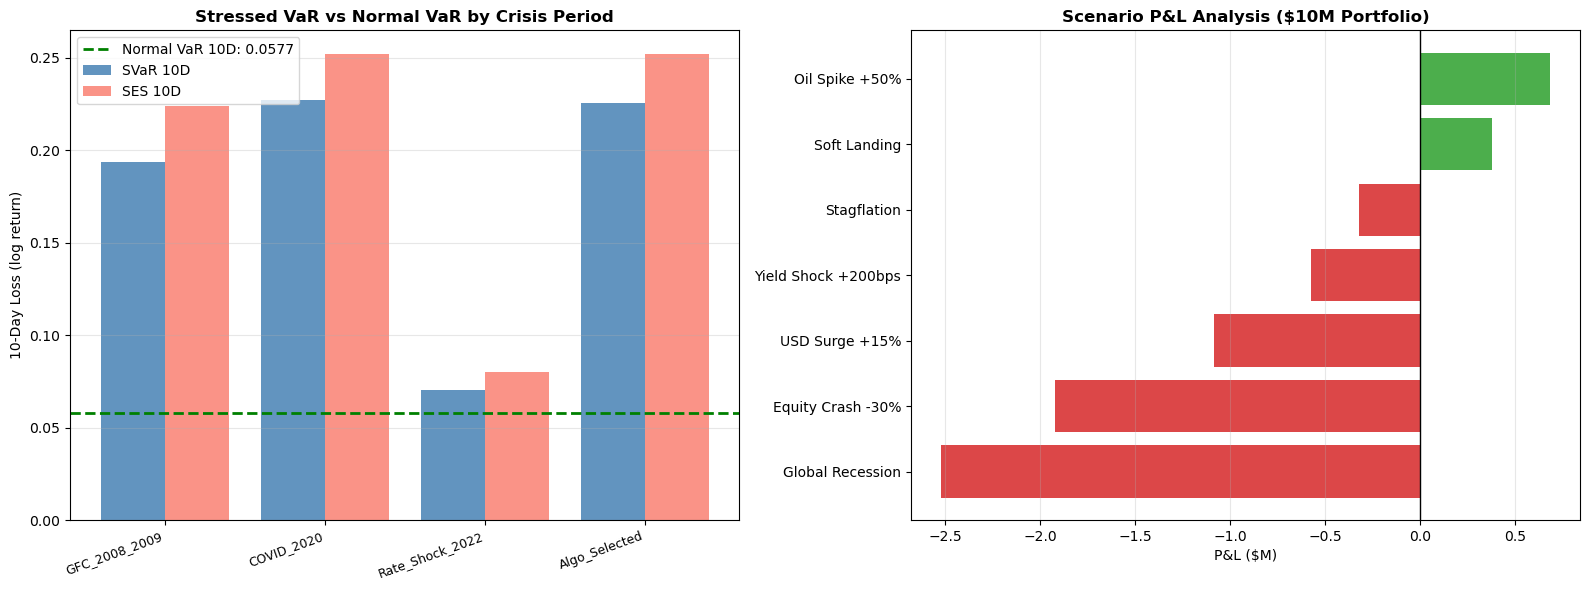


 Stressed VaR and scenario data saved.


In [7]:
# ── 5. Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
x  = range(len(stressed_df))
ax.bar([i - 0.2 for i in x], abs(stressed_df['VaR 1D']) * np.sqrt(10), width=0.4,
       label='SVaR 10D', color='steelblue', alpha=0.85)
ax.bar([i + 0.2 for i in x], abs(stressed_df['SES 10D']), width=0.4,
       label='SES 10D', color='salmon', alpha=0.85)
ax.axhline(abs(normal_var10), color='green', linestyle='--', lw=2,
           label=f'Normal VaR 10D: {abs(normal_var10):.4f}')
ax.set_xticks(list(x))
ax.set_xticklabels(stressed_df['Stress Period'], rotation=20, ha='right', fontsize=9)
ax.set_title('Stressed VaR vs Normal VaR by Crisis Period', fontweight='bold')
ax.set_ylabel('10-Day Loss (log return)')
ax.legend()
ax.grid(alpha=0.3, axis='y')

ax2  = axes[1]
bars = ax2.barh(scen_df['Scenario'],
                scen_df['P&L ($)'] / 1e6,
                color=['#d62728' if v < 0 else '#2ca02c' for v in scen_df['P&L ($)']],
                alpha=0.85)
ax2.axvline(0, color='black', lw=1)
ax2.set_xlabel('P&L ($M)')
ax2.set_title('Scenario P&L Analysis ($10M Portfolio)', fontweight='bold')
ax2.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig6_stressed_var_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()

stressed_df.to_csv(os.path.join(DATA_DIR, 'stressed_var.csv'), index=False)
scen_df.to_csv(os.path.join(DATA_DIR, 'scenario_pnl.csv'), index=False)
print('\n Stressed VaR and scenario data saved.')